# <b> Data Processing & Forecasting

# Overview

In this part of the capstone project, Load and clean the dataset.
The notebook covers data preprocessing, performing descriptive statistics for key numeric values, visualising, analysing customer feedback text for frequent used words, Correlating sentiment scores with order values

In [336]:
import pandas as pd
customer_feedback = pd.read_csv(r'C:\Users\User\Blinkit\blinkit_customer_feedback.csv')
customer_feedback

,feedback_id,order_id,customer_id,rating,feedback_text,feedback_category,sentiment,feedback_date
0,2234710,1961864118,30065862,4,"It was okay, nothing special.",Delivery,Neutral,7/17/2024
1,5450964,1549769649,9573071,3,The order was incorrect.,App Experience,Negative,5/28/2024
2,482108,9185164487,45477575,3,"It was okay, nothing special.",App Experience,Neutral,9/23/2024
3,4823104,9644738826,88067569,4,The product met my expectations.,App Experience,Neutral,11/24/2023
4,3537464,5427684290,83298567,3,Product was damaged during delivery.,Delivery,Negative,11/20/2023
...,...,...,...,...,...,...,...,...
4995,9024060,1669690997,62600289,3,Taste was not as expected.,Product Quality,Negative,12/25/2023
4996,4715968,8340761903,53640286,3,"Average experience, could improve.",Product Quality,Neutral,11/27/2023
4997,9621021,5936301790,87059497,4,"Average experience, could improve.",App Experience,Neutral,6/21/2024
4998,1134095,5710579377,67310893,4,"Average experience, could improve.",Delivery,Neutral,6/6/2024


## <b> Data Inspection: Info, Nulls, Duplicates, and Description


Before cleaning or modeling, we perform an initial inspection of the dataset. This step uses key methods: **.info()** to check data types and non-null counts, **.isnull().sum()** to identify the total number of missing values per column, **.duplicated().sum()** to count any duplicate rows, and **.describe()** to view the statistical summary of numerical features. This ensures data quality and readiness for preprocessing.

In [337]:
customer_feedback.duplicated().sum()

np.int64(0)

In [338]:
customer_feedback.dtypes

feedback_id          int64
order_id             int64
customer_id          int64
rating               int64
feedback_text          str
feedback_category      str
sentiment              str
feedback_date          str
dtype: object

In [339]:
customer_feedback["feedback_date"] = pd.to_datetime(customer_feedback["feedback_date"])

In [340]:
customer_feedback.dtypes

feedback_id                   int64
order_id                      int64
customer_id                   int64
rating                        int64
feedback_text                   str
feedback_category               str
sentiment                       str
feedback_date        datetime64[us]
dtype: object

In [341]:
customer_feedback.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   feedback_id        5000 non-null   int64         
 1   order_id           5000 non-null   int64         
 2   customer_id        5000 non-null   int64         
 3   rating             5000 non-null   int64         
 4   feedback_text      5000 non-null   str           
 5   feedback_category  5000 non-null   str           
 6   sentiment          5000 non-null   str           
 7   feedback_date      5000 non-null   datetime64[us]
dtypes: datetime64[us](1), int64(4), str(3)
memory usage: 312.6 KB


In [342]:
customer_feedback.isnull().sum()

feedback_id          0
order_id             0
customer_id          0
rating               0
feedback_text        0
feedback_category    0
sentiment            0
feedback_date        0
dtype: int64

In [343]:
customer_feedback["feedback_date"]=customer_feedback["feedback_date"].fillna(customer_feedback["feedback_date"].mode())

In [344]:
customer_feedback["feedback_text"]=customer_feedback["feedback_text"].str.strip().str.lower()

In [345]:
customer_feedback["feedback_id"] = (
    customer_feedback["feedback_id"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [346]:
customer_feedback["feedback_id"]=customer_feedback["feedback_id"].str.strip().str.lower()

In [347]:
customer_feedback["order_id"] = (
    customer_feedback["order_id"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [348]:
customer_feedback["order_id"]=customer_feedback["order_id"].str.strip().str.lower()

In [349]:
customer_feedback["customer_id"] = (
    customer_feedback["customer_id"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [350]:
customer_feedback["customer_id"]=customer_feedback["customer_id"].str.strip().str.lower()

In [351]:
customer_feedback["rating"] = (
    customer_feedback["rating"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [352]:
customer_feedback["rating"]=customer_feedback["rating"].str.strip().str.lower()

In [353]:
customer_feedback["feedback_text"]=customer_feedback["feedback_text"].str.strip().str.lower()

In [354]:
customer_feedback["feedback_category"]=customer_feedback["feedback_category"].str.strip().str.lower()

In [355]:
customer_feedback["feedback_date"] = (
    customer_feedback["feedback_date"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [356]:
customer_feedback["feedback_date"]=customer_feedback["feedback_date"].str.strip().str.lower()

In [357]:
customer_feedback["sentiment"]=customer_feedback["sentiment"].str.strip().str.lower()

In [358]:
customer_feedback.head(5)

,feedback_id,order_id,customer_id,rating,feedback_text,feedback_category,sentiment,feedback_date
0,2234710,1961864118,30065862,4,"it was okay, nothing special.",delivery,neutral,2024-07-17
1,5450964,1549769649,9573071,3,the order was incorrect.,app experience,negative,2024-05-28
2,482108,9185164487,45477575,3,"it was okay, nothing special.",app experience,neutral,2024-09-23
3,4823104,9644738826,88067569,4,the product met my expectations.,app experience,neutral,2023-11-24
4,3537464,5427684290,83298567,3,product was damaged during delivery.,delivery,negative,2023-11-20


In [359]:
import pandas as pd
customers = pd.read_csv(r'C:\Users\User\Blinkit\blinkit_customers.csv')
customers

,customer_id,customer_name,email,phone,address,area,pincode,registration_date,customer_segment,total_orders,avg_order_value
0,97475543,Niharika Nagi,ektataneja@example.org,9.129880e+11,"23, Nayar Path, Bihar Sharif-154625",Udupi,321865,5/13/2023,Premium,13,451.92
1,22077605,Megha Sachar,vedant45@example.com,9.151230e+11,"51/302, Buch Chowk\nSrinagar-570271",Aligarh,149394,6/18/2024,Inactive,4,825.48
2,47822591,Hema Bahri,samiazaan@example.com,9.100340e+11,"941\nAnne Street, Darbhanga 186125",Begusarai,621411,9/25/2024,Regular,17,1969.81
3,79726146,Zaitra Vig,ishanvi87@example.org,9.162640e+11,"43/94, Ghosh, Alappuzha 635655",Kozhikode,826054,10/4/2023,New,4,220.09
4,57102800,Januja Verma,atideshpande@example.org,9.172940e+11,"06\nOm, Ambarnath 477463",Ichalkaranji,730539,3/22/2024,Inactive,14,578.14
...,...,...,...,...,...,...,...,...,...,...,...
2495,48002829,Daksh Mandal,varkeymohammed@example.com,9.195880e+11,"28/42, Venkataraman Ganj, Kishanganj-360157",Mumbai,45238,1/25/2024,Inactive,17,754.33
2496,57392064,Lavanya Jain,deshpandeom@example.com,9.161370e+11,"391, Edwin Path, Korba 202726",Udupi,688100,6/23/2024,Regular,4,1540.81
2497,71688530,Umang Dash,gokhalenicholas@example.org,9.175950e+11,"151, Parmer Ganj\nLoni 906431",Kavali,528749,3/18/2024,Regular,1,1541.22
2498,89051578,Zinal Natarajan,vyasfrado@example.com,9.119940e+11,"H.No. 172, Khanna Street, Pudukkottai 610564",Alwar,586734,9/6/2024,Premium,12,1185.50


In [360]:
customers.duplicated().sum()

np.int64(0)

In [361]:
customers.dtypes

customer_id            int64
customer_name            str
email                    str
phone                float64
address                  str
area                     str
pincode                int64
registration_date        str
customer_segment         str
total_orders           int64
avg_order_value      float64
dtype: object

In [362]:
customers["registration_date"] = pd.to_datetime(customers["registration_date"])

In [363]:
customers.dtypes

customer_id                   int64
customer_name                   str
email                           str
phone                       float64
address                         str
area                            str
pincode                       int64
registration_date    datetime64[us]
customer_segment                str
total_orders                  int64
avg_order_value             float64
dtype: object

In [364]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        2500 non-null   int64         
 1   customer_name      2500 non-null   str           
 2   email              2500 non-null   str           
 3   phone              2500 non-null   float64       
 4   address            2500 non-null   str           
 5   area               2500 non-null   str           
 6   pincode            2500 non-null   int64         
 7   registration_date  2500 non-null   datetime64[us]
 8   customer_segment   2500 non-null   str           
 9   total_orders       2500 non-null   int64         
 10  avg_order_value    2500 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(3), str(5)
memory usage: 215.0 KB


In [365]:
customers.isnull().sum()

customer_id          0
customer_name        0
email                0
phone                0
address              0
area                 0
pincode              0
registration_date    0
customer_segment     0
total_orders         0
avg_order_value      0
dtype: int64

In [366]:
customers["registration_date"]=customers["registration_date"].fillna(customers["registration_date"].mode())

In [367]:
customers["customer_id"] = (
    customers["customer_id"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)



In [368]:
customers["customer_id"]=customers["customer_id"].str.strip().str.lower()

In [369]:
customers["customer_name"]=customers["customer_name"].str.strip().str.lower()

In [370]:
customers["email"]=customers["email"].str.strip().str.lower()

In [371]:
customers["phone"] = (
    customers["phone"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [372]:
customers["phone"]=customers["phone"].str.strip().str.lower()

In [373]:
customers["address"]=customers["address"].str.strip().str.lower()

In [374]:
customers["area"]=customers["area"].str.strip().str.lower()

In [375]:
customers["pincode"] = (
    customers["pincode"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [376]:
customers["pincode"]=customers["pincode"].str.strip().str.lower()

In [377]:
customers["registration_date"] = (
    customers["registration_date"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [378]:
customers["registration_date"]=customers["registration_date"].str.strip().str.lower()

In [379]:
customers["customer_segment"]=customers["customer_segment"].str.strip().str.lower()

In [380]:
customers["total_orders"] = (
    customers["total_orders"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [381]:
customers["total_orders"]=customers["total_orders"].str.strip().str.lower()

In [382]:
customers["avg_order_value"] = (
    customers["avg_order_value"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [383]:
customers["avg_order_value"]=customers["avg_order_value"].str.strip().str.lower()

In [384]:
customers.head(5)

,customer_id,customer_name,email,phone,address,area,pincode,registration_date,customer_segment,total_orders,avg_order_value
0,97475543,niharika nagi,ektataneja@example.org,912988000000.0,"23, nayar path, bihar sharif-154625",udupi,321865,2023-05-13,premium,13,451.92
1,22077605,megha sachar,vedant45@example.com,915123000000.0,"51/302, buch chowk\nsrinagar-570271",aligarh,149394,2024-06-18,inactive,4,825.48
2,47822591,hema bahri,samiazaan@example.com,910034000000.0,"941\nanne street, darbhanga 186125",begusarai,621411,2024-09-25,regular,17,1969.81
3,79726146,zaitra vig,ishanvi87@example.org,916264000000.0,"43/94, ghosh, alappuzha 635655",kozhikode,826054,2023-10-04,new,4,220.09
4,57102800,januja verma,atideshpande@example.org,917294000000.0,"06\nom, ambarnath 477463",ichalkaranji,730539,2024-03-22,inactive,14,578.14


In [7]:
import pandas as pd
delivery_performance = pd.read_csv(r'C:\Users\User\Blinkit\blinkit_delivery_performance.csv')
delivery_performance

,order_id,delivery_partner_id,promised_time,actual_time,delivery_time_minutes,distance_km,delivery_status,reasons_if_delayed
0,1961864118,63230,7/17/2024 8:52,7/17/2024 8:47,-5,0.96,On Time,NaN
1,1549769649,14983,5/28/2024 13:25,5/28/2024 13:27,2,0.98,On Time,Traffic
2,9185164487,39859,9/23/2024 13:25,9/23/2024 13:29,4,3.83,On Time,Traffic
3,9644738826,61497,11/24/2023 16:34,11/24/2023 16:33,-1,2.76,On Time,NaN
4,5427684290,84315,11/20/2023 5:17,11/20/2023 5:18,1,2.63,On Time,Traffic
...,...,...,...,...,...,...,...,...
4995,1669690997,90914,12/25/2023 16:05,12/25/2023 16:10,5,1.86,On Time,Traffic
4996,8340761903,27952,11/27/2023 9:38,11/27/2023 9:36,-2,3.31,On Time,NaN
4997,5936301790,9590,6/21/2024 19:23,6/21/2024 19:26,3,2.44,On Time,Traffic
4998,5710579377,29940,6/6/2024 15:12,6/6/2024 15:10,-2,1.76,On Time,NaN


In [8]:
delivery_performance.duplicated().sum()

np.int64(0)

In [9]:
delivery_performance.dtypes


order_id                   int64
delivery_partner_id        int64
promised_time                str
actual_time                  str
delivery_time_minutes      int64
distance_km              float64
delivery_status              str
reasons_if_delayed           str
dtype: object

In [388]:
delivery_performance["promised_time"] = pd.to_datetime(delivery_performance["promised_time"])



In [389]:
delivery_performance["actual_time"] = pd.to_datetime(delivery_performance["actual_time"])

In [390]:
delivery_performance.dtypes

order_id                          int64
delivery_partner_id               int64
promised_time            datetime64[us]
actual_time              datetime64[us]
delivery_time_minutes             int64
distance_km                     float64
delivery_status                     str
reasons_if_delayed                  str
dtype: object

In [391]:
delivery_performance.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               5000 non-null   int64         
 1   delivery_partner_id    5000 non-null   int64         
 2   promised_time          5000 non-null   datetime64[us]
 3   actual_time            5000 non-null   datetime64[us]
 4   delivery_time_minutes  5000 non-null   int64         
 5   distance_km            5000 non-null   float64       
 6   delivery_status        5000 non-null   str           
 7   reasons_if_delayed     3098 non-null   str           
dtypes: datetime64[us](2), float64(1), int64(3), str(2)
memory usage: 312.6 KB


In [392]:
delivery_performance.isnull().sum()

order_id                    0
delivery_partner_id         0
promised_time               0
actual_time                 0
delivery_time_minutes       0
distance_km                 0
delivery_status             0
reasons_if_delayed       1902
dtype: int64

In [393]:
delivery_performance["promised_time"]=delivery_performance["promised_time"].fillna(delivery_performance["promised_time"].mode())



In [394]:
delivery_performance["actual_time"]=delivery_performance["actual_time"].fillna(delivery_performance["actual_time"].mode())

In [395]:
delivery_performance["order_id"] = (
    delivery_performance["order_id"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [396]:
delivery_performance["order_id"]=delivery_performance["order_id"].str.strip().str.lower()

In [397]:
delivery_performance["delivery_partner_id"] = (
    delivery_performance["delivery_partner_id"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [398]:
delivery_performance["delivery_partner_id"]=delivery_performance["delivery_partner_id"].str.strip().str.lower()

In [399]:
delivery_performance["promised_time"] = (
    delivery_performance["promised_time"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [400]:
delivery_performance["promised_time"]=delivery_performance["promised_time"].str.strip().str.lower()

In [401]:
delivery_performance["actual_time"] = (
    delivery_performance["actual_time"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [402]:
delivery_performance["actual_time"]=delivery_performance["actual_time"].str.strip().str.lower()

In [403]:
delivery_performance["delivery_time_minutes"] = (
    delivery_performance["delivery_time_minutes"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [404]:
delivery_performance["delivery_time_minutes"]=delivery_performance["delivery_time_minutes"].str.strip().str.lower()

In [405]:
delivery_performance["distance_km"] = (
    delivery_performance["distance_km"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [406]:
delivery_performance["distance_km"]=delivery_performance["distance_km"].str.strip().str.lower()

In [407]:
delivery_performance["delivery_status"]=delivery_performance["delivery_status"].str.strip().str.lower()

In [408]:
delivery_performance["reasons_if_delayed"]=delivery_performance["reasons_if_delayed"].str.strip().str.lower()

In [409]:
delivery_performance.head(5)

,order_id,delivery_partner_id,promised_time,actual_time,delivery_time_minutes,distance_km,delivery_status,reasons_if_delayed
0,1961864118,63230,2024-07-17 08:52:00,2024-07-17 08:47:00,-5,0.96,on time,NaN
1,1549769649,14983,2024-05-28 13:25:00,2024-05-28 13:27:00,2,0.98,on time,traffic
2,9185164487,39859,2024-09-23 13:25:00,2024-09-23 13:29:00,4,3.83,on time,traffic
3,9644738826,61497,2023-11-24 16:34:00,2023-11-24 16:33:00,-1,2.76,on time,NaN
4,5427684290,84315,2023-11-20 05:17:00,2023-11-20 05:18:00,1,2.63,on time,traffic


In [410]:
import pandas as pd
inventory = pd.read_csv(r'C:\Users\User\Blinkit\Blinkit_inventory.csv')
inventory


,product_id,date,stock_received,damaged_stock
0,153019,17-03-2023,4,2
1,848226,17-03-2023,4,2
2,965755,17-03-2023,1,0
3,39154,17-03-2023,4,0
4,34186,17-03-2023,3,2
...,...,...,...,...
75167,298985,5/11/2024,3,0
75168,679284,5/11/2024,3,0
75169,240179,5/11/2024,3,0
75170,673058,5/11/2024,3,2


In [411]:
inventory.duplicated().sum()

np.int64(0)

In [412]:
inventory.dtypes

product_id        int64
date                str
stock_received    int64
damaged_stock     int64
dtype: object

In [413]:
inventory["date"] = pd.to_datetime(inventory["date"], errors="coerce", format="mixed")



In [414]:
inventory.dtypes

product_id                 int64
date              datetime64[us]
stock_received             int64
damaged_stock              int64
dtype: object

In [415]:
inventory.info()

<class 'pandas.DataFrame'>
RangeIndex: 75172 entries, 0 to 75171
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   product_id      75172 non-null  int64         
 1   date            75172 non-null  datetime64[us]
 2   stock_received  75172 non-null  int64         
 3   damaged_stock   75172 non-null  int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 2.3 MB


In [416]:
inventory.isnull().sum()

product_id        0
date              0
stock_received    0
damaged_stock     0
dtype: int64

In [417]:
inventory["feedback_date"]=inventory["date"].fillna(inventory["date"].mode())

In [418]:
inventory["product_id"] = (
    inventory["product_id"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [419]:
inventory["product_id"]=inventory["product_id"].str.strip().str.lower()

In [420]:
inventory["date"] = (
    inventory["date"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [421]:
inventory["date"]=inventory["date"].str.strip().str.lower()

In [422]:
inventory["stock_received"] = (
    inventory["stock_received"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [423]:
inventory["stock_received"]=inventory["stock_received"].str.strip().str.lower()

In [424]:
inventory["damaged_stock"] = (
    inventory["damaged_stock"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [425]:
inventory["damaged_stock"]=inventory["damaged_stock"].str.strip().str.lower()

In [426]:
inventory.head(5)

,product_id,date,stock_received,damaged_stock,feedback_date
0,153019,2023-03-17,4,2,2023-03-17
1,848226,2023-03-17,4,2,2023-03-17
2,965755,2023-03-17,1,0,2023-03-17
3,39154,2023-03-17,4,0,2023-03-17
4,34186,2023-03-17,3,2,2023-03-17


In [427]:
import pandas as pd
Inventory_New = pd.read_csv(r'C:\Users\User\Blinkit\blinkit_inventoryNew.csv')
Inventory_New

,product_id,date,stock_received,damaged_stock
0,153019,23-Mar,4,1
1,848226,23-Mar,4,1
2,965755,23-Mar,1,0
3,39154,23-Mar,4,0
4,34186,23-Mar,3,1
...,...,...,...,...
18100,837480,24-Nov,3,0
18101,56589,24-Nov,3,0
18102,679284,24-Nov,3,0
18103,673058,24-Nov,3,0


In [428]:
Inventory_New.duplicated().sum()

np.int64(7359)

In [429]:
Inventory_New.dtypes

product_id        int64
date                str
stock_received    int64
damaged_stock     int64
dtype: object

In [430]:
Inventory_New["date"] = pd.to_datetime(
    Inventory_New["date"], errors='coerce'
)

C:\Users\User\AppData\Local\Temp\ipykernel_13596\3307651575.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Inventory_New["date"] = pd.to_datetime(


In [431]:
Inventory_New.dtypes

product_id                 int64
date              datetime64[us]
stock_received             int64
damaged_stock              int64
dtype: object

In [432]:
Inventory_New.info()

<class 'pandas.DataFrame'>
RangeIndex: 18105 entries, 0 to 18104
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   product_id      18105 non-null  int64         
 1   date            18105 non-null  datetime64[us]
 2   stock_received  18105 non-null  int64         
 3   damaged_stock   18105 non-null  int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 565.9 KB


In [433]:
Inventory_New.isnull().sum()

product_id        0
date              0
stock_received    0
damaged_stock     0
dtype: int64

In [434]:
Inventory_New["date"]= Inventory_New["date"].fillna(Inventory_New["date"].mode())

In [435]:
Inventory_New["product_id"] = (
    Inventory_New["product_id"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [436]:
Inventory_New["product_id"]= Inventory_New["product_id"].str.strip().str.lower()

In [437]:
Inventory_New["date"] = (
    Inventory_New["date"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [438]:
Inventory_New["date"]= Inventory_New["date"].str.strip().str.lower()

In [439]:
Inventory_New["stock_received"] = (
    Inventory_New["stock_received"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [440]:
Inventory_New["stock_received"]= Inventory_New["stock_received"].str.strip().str.lower()

In [441]:
Inventory_New["damaged_stock"] = (
    Inventory_New["damaged_stock"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [442]:
Inventory_New["damaged_stock"]= Inventory_New["damaged_stock"].str.strip().str.lower()

In [443]:
Inventory_New.head(5)

,product_id,date,stock_received,damaged_stock
0,153019,1-03-23,4,1
1,848226,1-03-23,4,1
2,965755,1-03-23,1,0
3,39154,1-03-23,4,0
4,34186,1-03-23,3,1


In [444]:
import pandas as pd
marketing_performance = pd.read_csv(r'C:\Users\User\Blinkit\blinkit_marketing_performance.csv')
marketing_performance


,campaign_id,campaign_name,date,target_audience,channel,impressions,clicks,conversions,spend,revenue_generated,roas
0,548299,New User Discount,11/5/2024,Premium,App,3130,163,78,1431.85,4777.75,3.60
1,390914,Weekend Special,11/5/2024,Inactive,App,3925,494,45,4506.34,6238.11,2.98
2,834385,Festival Offer,11/5/2024,Inactive,Email,7012,370,78,4524.23,2621.00,2.95
3,241523,Flash Sale,11/5/2024,Inactive,SMS,1115,579,86,3622.79,2955.00,2.84
4,595111,Membership Drive,11/5/2024,New Users,Email,7172,795,54,2888.99,8951.81,2.22
...,...,...,...,...,...,...,...,...,...,...,...
5395,381623,Membership Drive,3/17/2023,New Users,Email,8331,809,92,2363.07,3710.79,1.64
5396,493317,Category Promotion,3/17/2023,Premium,Social Media,5216,860,34,3922.53,7701.25,2.01
5397,879292,App Push Notification,3/17/2023,All,App,8480,734,20,1990.75,6650.41,3.98
5398,461129,Email Campaign,3/17/2023,New Users,Email,3569,568,10,4246.47,5880.42,2.50


In [445]:
marketing_performance.duplicated().sum()

np.int64(0)

In [446]:
marketing_performance.dtypes

campaign_id            int64
campaign_name            str
date                     str
target_audience          str
channel                  str
impressions            int64
clicks                 int64
conversions            int64
spend                float64
revenue_generated    float64
roas                 float64
dtype: object

In [447]:
marketing_performance["calculated_roas"] = marketing_performance["revenue_generated"] / marketing_performance["spend"]

In [448]:
marketing_performance[["roas", "calculated_roas"]].head()

,roas,calculated_roas
0,3.60,3.336767
1,2.98,1.384296
2,2.95,0.579325
3,2.84,0.815670
4,2.22,3.098595


In [449]:
marketing_performance["date"] = pd.to_datetime(marketing_performance["date"], errors="coerce", dayfirst=True)

In [450]:
marketing_performance.dtypes

campaign_id                   int64
campaign_name                   str
date                 datetime64[us]
target_audience                 str
channel                         str
impressions                   int64
clicks                        int64
conversions                   int64
spend                       float64
revenue_generated           float64
roas                        float64
calculated_roas             float64
dtype: object

In [451]:
marketing_performance.dtypes.info()

<class 'pandas.Series'>
Index: 12 entries, campaign_id to calculated_roas
Series name: None
Non-Null Count  Dtype 
--------------  ----- 
12 non-null     object
dtypes: object(1)
memory usage: 492.0+ bytes


In [452]:
marketing_performance.isnull().sum()

campaign_id             0
campaign_name           0
date                 3303
target_audience         0
channel                 0
impressions             0
clicks                  0
conversions             0
spend                   0
revenue_generated       0
roas                    0
calculated_roas         0
dtype: int64

In [453]:
marketing_performance["date"].dtype

dtype('<M8[us]')

In [454]:
marketing_performance[marketing_performance["date"].isna()].head()

,campaign_id,campaign_name,date,target_audience,channel,impressions,clicks,conversions,spend,revenue_generated,roas,calculated_roas
45,795261,New User Discount,NaT,New Users,Email,7876,977,73,1813.53,6438.12,3.73,3.550049
46,601445,Weekend Special,NaT,Inactive,SMS,5624,386,70,3572.92,5202.67,1.96,1.456140
47,830587,Festival Offer,NaT,Inactive,App,1081,662,47,2001.90,3301.92,3.52,1.649393
48,706750,Flash Sale,NaT,Premium,App,4511,338,27,1645.66,2073.23,2.57,1.259817
49,584256,Membership Drive,NaT,Inactive,SMS,1810,750,44,1279.23,5722.42,2.73,4.473332


In [455]:
len(marketing_performance)

5400

In [456]:
marketing_performance["date"].iloc[45:50]

45   NaT
46   NaT
47   NaT
48   NaT
49   NaT
Name: date, dtype: datetime64[us]

In [457]:
marketing_performance["date"] = pd.to_datetime(
    marketing_performance["date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

In [458]:
marketing_performance[marketing_performance["date"].isna()]

,campaign_id,campaign_name,date,target_audience,channel,impressions,clicks,conversions,spend,revenue_generated,roas,calculated_roas
45,795261,New User Discount,NaT,New Users,Email,7876,977,73,1813.53,6438.12,3.73,3.550049
46,601445,Weekend Special,NaT,Inactive,SMS,5624,386,70,3572.92,5202.67,1.96,1.456140
47,830587,Festival Offer,NaT,Inactive,App,1081,662,47,2001.90,3301.92,3.52,1.649393
48,706750,Flash Sale,NaT,Premium,App,4511,338,27,1645.66,2073.23,2.57,1.259817
49,584256,Membership Drive,NaT,Inactive,SMS,1810,750,44,1279.23,5722.42,2.73,4.473332
...,...,...,...,...,...,...,...,...,...,...,...,...
5395,381623,Membership Drive,NaT,New Users,Email,8331,809,92,2363.07,3710.79,1.64,1.570326
5396,493317,Category Promotion,NaT,Premium,Social Media,5216,860,34,3922.53,7701.25,2.01,1.963337
5397,879292,App Push Notification,NaT,All,App,8480,734,20,1990.75,6650.41,3.98,3.340656
5398,461129,Email Campaign,NaT,New Users,Email,3569,568,10,4246.47,5880.42,2.50,1.384778


In [459]:
marketing_performance = pd.read_csv(r'C:\Users\User\Blinkit\blinkit_marketing_performance.csv')
marketing_performance

,campaign_id,campaign_name,date,target_audience,channel,impressions,clicks,conversions,spend,revenue_generated,roas
0,548299,New User Discount,11/5/2024,Premium,App,3130,163,78,1431.85,4777.75,3.60
1,390914,Weekend Special,11/5/2024,Inactive,App,3925,494,45,4506.34,6238.11,2.98
2,834385,Festival Offer,11/5/2024,Inactive,Email,7012,370,78,4524.23,2621.00,2.95
3,241523,Flash Sale,11/5/2024,Inactive,SMS,1115,579,86,3622.79,2955.00,2.84
4,595111,Membership Drive,11/5/2024,New Users,Email,7172,795,54,2888.99,8951.81,2.22
...,...,...,...,...,...,...,...,...,...,...,...
5395,381623,Membership Drive,3/17/2023,New Users,Email,8331,809,92,2363.07,3710.79,1.64
5396,493317,Category Promotion,3/17/2023,Premium,Social Media,5216,860,34,3922.53,7701.25,2.01
5397,879292,App Push Notification,3/17/2023,All,App,8480,734,20,1990.75,6650.41,3.98
5398,461129,Email Campaign,3/17/2023,New Users,Email,3569,568,10,4246.47,5880.42,2.50


In [460]:
marketing_performance["date"].head(40)

0     11/5/2024
1     11/5/2024
2     11/5/2024
3     11/5/2024
4     11/5/2024
5     11/5/2024
6     11/5/2024
7     11/5/2024
8     11/5/2024
9     11/4/2024
10    11/4/2024
11    11/4/2024
12    11/4/2024
13    11/4/2024
14    11/4/2024
15    11/4/2024
16    11/4/2024
17    11/4/2024
18    11/3/2024
19    11/3/2024
20    11/3/2024
21    11/3/2024
22    11/3/2024
23    11/3/2024
24    11/3/2024
25    11/3/2024
26    11/3/2024
27    11/2/2024
28    11/2/2024
29    11/2/2024
30    11/2/2024
31    11/2/2024
32    11/2/2024
33    11/2/2024
34    11/2/2024
35    11/2/2024
36    11/1/2024
37    11/1/2024
38    11/1/2024
39    11/1/2024
Name: date, dtype: str

In [461]:
marketing_performance["date"] = pd.to_datetime(
    marketing_performance["date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

In [462]:
marketing_performance["date"].isna().sum()

np.int64(0)

In [463]:
marketing_performance["roas"] = marketing_performance["revenue_generated"] / marketing_performance["spend"]

In [464]:
marketing_performance.isnull().sum()

campaign_id          0
campaign_name        0
date                 0
target_audience      0
channel              0
impressions          0
clicks               0
conversions          0
spend                0
revenue_generated    0
roas                 0
dtype: int64

In [465]:
marketing_performance["date"]=marketing_performance["date"].fillna(marketing_performance["date"].mode())


In [466]:
marketing_performance.dtypes

campaign_id                   int64
campaign_name                   str
date                 datetime64[us]
target_audience                 str
channel                         str
impressions                   int64
clicks                        int64
conversions                   int64
spend                       float64
revenue_generated           float64
roas                        float64
dtype: object

In [467]:
marketing_performance["date"] = (
    marketing_performance["date"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [468]:
marketing_performance["date"]= marketing_performance["date"].str.strip().str.lower()

In [469]:
marketing_performance["campaign_id"] = (
    marketing_performance["campaign_id"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [470]:
marketing_performance["campaign_id"]= marketing_performance["campaign_id"].str.strip().str.lower()

In [471]:
marketing_performance["campaign_name"]= marketing_performance["campaign_name"].str.strip().str.lower()

In [472]:
marketing_performance["target_audience"]= marketing_performance["target_audience"].str.strip().str.lower()

In [473]:
marketing_performance["channel"]= marketing_performance["channel"].str.strip().str.lower()

In [474]:
marketing_performance["impressions"] = (
    marketing_performance["impressions"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [475]:
marketing_performance["impressions"]= marketing_performance["impressions"].str.strip().str.lower()

In [476]:
marketing_performance["clicks"] = (
    marketing_performance["clicks"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [477]:
marketing_performance["clicks"]= marketing_performance["clicks"].str.strip().str.lower()

In [478]:
marketing_performance["conversions"] = (
    marketing_performance["conversions"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [479]:
marketing_performance["conversions"]= marketing_performance["conversions"].str.strip().str.lower()

In [480]:
marketing_performance["spend"] = (
    marketing_performance["spend"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [481]:
marketing_performance["spend"]= marketing_performance["spend"].str.strip().str.lower()

In [482]:
marketing_performance["revenue_generated"] = (
    marketing_performance["revenue_generated"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [483]:
marketing_performance["revenue_generated"]= marketing_performance["revenue_generated"].str.strip().str.lower()

In [484]:
marketing_performance["roas"] = (
    marketing_performance["roas"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [485]:
marketing_performance["roas"]= marketing_performance["roas"].str.strip().str.lower()

In [486]:
marketing_performance.head(10)

,campaign_id,campaign_name,date,target_audience,channel,impressions,clicks,conversions,spend,revenue_generated,roas
0,548299,new user discount,2024-05-11,premium,app,3130,163,78,1431.85,4777.75,3.3367671194608377
1,390914,weekend special,2024-05-11,inactive,app,3925,494,45,4506.34,6238.11,1.384296346924555
2,834385,festival offer,2024-05-11,inactive,email,7012,370,78,4524.23,2621.0,0.5793251006248578
3,241523,flash sale,2024-05-11,inactive,sms,1115,579,86,3622.79,2955.0,0.8156696910392267
4,595111,membership drive,2024-05-11,new users,email,7172,795,54,2888.99,8951.81,3.098595010713087
5,176344,category promotion,2024-05-11,inactive,app,4333,421,40,2714.78,6697.88,2.467190711586206
6,875646,app push notification,2024-05-11,premium,email,4752,937,21,3584.76,9152.99,2.553306218547406
7,5516,email campaign,2024-05-11,premium,social media,1559,418,68,1457.88,2156.09,1.4789214475814196
8,989534,referral program,2024-05-11,new users,sms,3838,911,45,4808.64,8074.17,1.6790963765222597
9,243346,new user discount,2024-04-11,inactive,sms,6289,834,14,3746.35,4474.02,1.1942343881377875


In [487]:
import pandas as pd
order_items = pd.read_csv(r'C:\Users\User\Blinkit\blinkit_order_items.csv')
order_items

,order_id,product_id,quantity,unit_price
0,1961864118,642612,3,517.03
1,1549769649,378676,1,881.42
2,9185164487,741341,2,923.84
3,9644738826,561860,1,874.78
4,5427684290,602241,2,976.55
...,...,...,...,...
4995,1669690997,925482,3,475.04
4996,8340761903,124290,2,39.65
4997,5936301790,491314,3,973.44
4998,5710579377,319388,2,657.80


In [488]:
order_items.duplicated().sum()

np.int64(0)

In [489]:
order_items.dtypes

order_id        int64
product_id      int64
quantity        int64
unit_price    float64
dtype: object

In [490]:
order_items.duplicated(subset=["order_id", "product_id"]).sum()

np.int64(0)

In [491]:
order_items[(order_items["quantity"] >= 0) | (order_items["unit_price"] >= 0)]

,order_id,product_id,quantity,unit_price
0,1961864118,642612,3,517.03
1,1549769649,378676,1,881.42
2,9185164487,741341,2,923.84
3,9644738826,561860,1,874.78
4,5427684290,602241,2,976.55
...,...,...,...,...
4995,1669690997,925482,3,475.04
4996,8340761903,124290,2,39.65
4997,5936301790,491314,3,973.44
4998,5710579377,319388,2,657.80


In [492]:
order_items["unit_price"]=order_items["unit_price"].fillna(order_items["unit_price"].mean())

In [493]:
order_items["order_id"] = (
    order_items["order_id"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [494]:
order_items["order_id"]= order_items["order_id"].str.strip().str.lower()


In [495]:
order_items["product_id"] = (
    order_items["product_id"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [496]:
order_items["product_id"]= order_items["product_id"].str.strip().str.lower()

In [497]:
order_items["quantity"] = (
    order_items["quantity"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [498]:
order_items["quantity"]= order_items["quantity"].str.strip().str.lower()

In [499]:
order_items["unit_price"] = (
    order_items["unit_price"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [500]:
order_items["unit_price"]= order_items["unit_price"].str.strip().str.lower()

In [501]:
order_items.head(10)

,order_id,product_id,quantity,unit_price
0,1961864118,642612,3,517.03
1,1549769649,378676,1,881.42
2,9185164487,741341,2,923.84
3,9644738826,561860,1,874.78
4,5427684290,602241,2,976.55
5,3265154092,681063,1,321.28
6,4898355547,56589,3,517.77
7,6568151549,500739,2,359.98
8,6006693867,490939,1,80.25
9,374186990,760828,2,563.45


In [502]:
import pandas as pd
orders = pd.read_csv(r'C:\Users\User\Blinkit\blinkit_orders.csv')
orders

,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id
0,1961864118,30065862,7/17/2024 8:34,7/17/2024 8:52,7/17/2024 8:47,On Time,3197.07,Cash,63230,4771
1,1549769649,9573071,5/28/2024 13:14,5/28/2024 13:25,5/28/2024 13:27,On Time,976.55,Cash,14983,7534
2,9185164487,45477575,9/23/2024 13:07,9/23/2024 13:25,9/23/2024 13:29,On Time,839.05,UPI,39859,9886
3,9644738826,88067569,11/24/2023 16:16,11/24/2023 16:34,11/24/2023 16:33,On Time,440.23,Card,61497,7917
4,5427684290,83298567,11/20/2023 5:00,11/20/2023 5:17,11/20/2023 5:18,On Time,2526.68,Cash,84315,2741
...,...,...,...,...,...,...,...,...,...,...
4995,1669690997,62600289,12/25/2023 15:46,12/25/2023 16:05,12/25/2023 16:10,On Time,1132.33,Cash,90914,1587
4996,8340761903,53640286,11/27/2023 9:18,11/27/2023 9:38,11/27/2023 9:36,On Time,2372.01,Cash,27952,3458
4997,5936301790,87059497,6/21/2024 19:09,6/21/2024 19:23,6/21/2024 19:26,On Time,3158.35,Cash,9590,7424
4998,5710579377,67310893,6/6/2024 14:58,6/6/2024 15:12,6/6/2024 15:10,On Time,1918.92,UPI,29940,6128


In [503]:
orders.duplicated().sum()

np.int64(0)

In [504]:
orders.dtypes

order_id                    int64
customer_id                 int64
order_date                    str
promised_delivery_time        str
actual_delivery_time          str
delivery_status               str
order_total               float64
payment_method                str
delivery_partner_id         int64
store_id                    int64
dtype: object

In [505]:
orders["order_date"] = pd.to_datetime(orders["order_date"])

In [506]:
orders["promised_delivery_time"] = pd.to_datetime(orders["promised_delivery_time"])

In [507]:
orders["actual_delivery_time"] = pd.to_datetime(orders["actual_delivery_time"])

In [508]:
orders.dtypes

order_id                           int64
customer_id                        int64
order_date                datetime64[us]
promised_delivery_time    datetime64[us]
actual_delivery_time      datetime64[us]
delivery_status                      str
order_total                      float64
payment_method                       str
delivery_partner_id                int64
store_id                           int64
dtype: object

In [509]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   order_id                5000 non-null   int64         
 1   customer_id             5000 non-null   int64         
 2   order_date              5000 non-null   datetime64[us]
 3   promised_delivery_time  5000 non-null   datetime64[us]
 4   actual_delivery_time    5000 non-null   datetime64[us]
 5   delivery_status         5000 non-null   str           
 6   order_total             5000 non-null   float64       
 7   payment_method          5000 non-null   str           
 8   delivery_partner_id     5000 non-null   int64         
 9   store_id                5000 non-null   int64         
dtypes: datetime64[us](3), float64(1), int64(4), str(2)
memory usage: 390.8 KB


In [510]:
orders.isnull().sum()

order_id                  0
customer_id               0
order_date                0
promised_delivery_time    0
actual_delivery_time      0
delivery_status           0
order_total               0
payment_method            0
delivery_partner_id       0
store_id                  0
dtype: int64

In [511]:
orders["order_total"]= orders["order_total"].fillna(orders["order_total"].mean())


In [512]:
orders["order_id"] = (
    orders["order_id"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [513]:
orders["order_id"]=orders["order_id"].str.strip().str.lower()

In [514]:
orders["customer_id"] = (
    orders["customer_id"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [515]:
orders["customer_id"]=orders["customer_id"].str.strip().str.lower()

In [516]:
orders["order_date"] = (
    orders["order_date"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [517]:
orders["order_date"]=orders["order_date"].str.strip().str.lower()

In [518]:
orders["promised_delivery_time"] = (
    orders["promised_delivery_time"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [519]:
orders["promised_delivery_time"]=orders["promised_delivery_time"].str.strip().str.lower()

In [520]:
orders["actual_delivery_time"] = (
    orders["actual_delivery_time"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [521]:
orders["actual_delivery_time"]=orders["actual_delivery_time"].str.strip().str.lower()

In [522]:
orders["delivery_status"]=orders["delivery_status"].str.strip().str.lower()

In [523]:
orders["payment_method"]=orders["payment_method"].str.strip().str.lower()

In [524]:
orders["order_total"] = (
    orders["order_total"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [525]:
orders["order_total"]=orders["order_total"].str.strip().str.lower()

In [526]:
orders["delivery_partner_id"] = (
    orders["delivery_partner_id"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [527]:
orders["delivery_partner_id"]=orders["delivery_partner_id"].str.strip().str.lower()

In [528]:
orders["store_id"] = (
    orders["store_id"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [529]:
orders["store_id"]=orders["store_id"].str.strip().str.lower()

In [530]:
orders.head(10)

,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id
0,1961864118,30065862,2024-07-17 08:34:00,2024-07-17 08:52:00,2024-07-17 08:47:00,on time,3197.07,cash,63230,4771
1,1549769649,9573071,2024-05-28 13:14:00,2024-05-28 13:25:00,2024-05-28 13:27:00,on time,976.55,cash,14983,7534
2,9185164487,45477575,2024-09-23 13:07:00,2024-09-23 13:25:00,2024-09-23 13:29:00,on time,839.05,upi,39859,9886
3,9644738826,88067569,2023-11-24 16:16:00,2023-11-24 16:34:00,2023-11-24 16:33:00,on time,440.23,card,61497,7917
4,5427684290,83298567,2023-11-20 05:00:00,2023-11-20 05:17:00,2023-11-20 05:18:00,on time,2526.68,cash,84315,2741
5,3265154092,43367112,2023-03-18 16:29:00,2023-03-18 16:49:00,2023-03-18 16:48:00,on time,3161.43,upi,554,3442
6,4898355547,13284996,2023-04-16 18:50:00,2023-04-16 19:01:00,2023-04-16 19:02:00,on time,956.4,card,14630,1318
7,6568151549,88866835,2024-03-31 06:26:00,2024-03-31 06:37:00,2024-03-31 06:39:00,on time,905.47,cash,67714,115
8,6006693867,24496983,2023-07-13 23:49:00,2023-07-14 00:02:00,2023-07-14 00:05:00,on time,1371.17,card,91362,9021
9,374186990,52215833,2023-08-09 01:17:00,2023-08-09 01:37:00,2023-08-09 01:44:00,slightly delayed,1601.19,wallet,77203,7955


In [531]:
import pandas as pd
products = pd.read_csv(r'C:\Users\User\Blinkit\blinkit_products.csv')
products


,product_id,product_name,category,brand,price,mrp,margin_percentage,shelf_life_days,min_stock_level,max_stock_level
0,153019,Onions,Fruits & Vegetables,Aurora LLC,947.95,1263.93,25,3,13,88
1,11422,Potatoes,Fruits & Vegetables,Ramaswamy-Tata,127.16,169.55,25,3,20,65
2,669378,Potatoes,Fruits & Vegetables,Chadha and Sons,212.14,282.85,25,3,23,70
3,848226,Tomatoes,Fruits & Vegetables,Barad and Sons,209.59,279.45,25,3,10,51
4,890623,Onions,Fruits & Vegetables,"Sangha, Nagar and Varty",354.52,472.69,25,3,27,55
...,...,...,...,...,...,...,...,...,...,...
263,444361,Pain Reliever,Pharmacy,"Prakash, Bawa and Kale",822.63,1028.29,20,365,20,71
264,679284,Cough Syrup,Pharmacy,Pant LLC,877.89,1097.36,20,365,28,95
265,240179,Cough Syrup,Pharmacy,Ram-Suri,90.56,113.20,20,365,20,56
266,673058,Cough Syrup,Pharmacy,Balan-Madan,765.76,957.20,20,365,30,94


In [532]:
products.duplicated().sum()

np.int64(0)

In [533]:
products.dtypes

product_id             int64
product_name             str
category                 str
brand                    str
price                float64
mrp                  float64
margin_percentage      int64
shelf_life_days        int64
min_stock_level        int64
max_stock_level        int64
dtype: object

In [534]:
products[products["price"] > products["mrp"]]

,product_id,product_name,category,brand,price,mrp,margin_percentage,shelf_life_days,min_stock_level,max_stock_level


In [535]:
calculated_margin = ((products["mrp"] - products["price"]) / products["mrp"]) * 100

In [536]:
(products["margin_percentage"] - calculated_margin).abs().sort_values(ascending=False).head()

21     0.014148
103    0.012453
169    0.005554
119    0.005445
136    0.004748
dtype: float64

In [537]:
products[products["min_stock_level"] > products["max_stock_level"]]

,product_id,product_name,category,brand,price,mrp,margin_percentage,shelf_life_days,min_stock_level,max_stock_level


In [538]:
products[products["shelf_life_days"] <= 0]

,product_id,product_name,category,brand,price,mrp,margin_percentage,shelf_life_days,min_stock_level,max_stock_level


In [539]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 268 entries, 0 to 267
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   product_id         268 non-null    int64  
 1   product_name       268 non-null    str    
 2   category           268 non-null    str    
 3   brand              268 non-null    str    
 4   price              268 non-null    float64
 5   mrp                268 non-null    float64
 6   margin_percentage  268 non-null    int64  
 7   shelf_life_days    268 non-null    int64  
 8   min_stock_level    268 non-null    int64  
 9   max_stock_level    268 non-null    int64  
dtypes: float64(2), int64(5), str(3)
memory usage: 21.1 KB


In [540]:
products.isnull().sum()

product_id           0
product_name         0
category             0
brand                0
price                0
mrp                  0
margin_percentage    0
shelf_life_days      0
min_stock_level      0
max_stock_level      0
dtype: int64

In [541]:
products["price"]=products["price"].fillna(products["price"].mean())

In [542]:
products["product_id"] = (
    products["product_id"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [543]:
products["product_id"]=products["product_id"].str.strip().str.lower()

In [544]:
products["product_name"]=products["product_name"].str.strip().str.lower()

In [545]:
products["category"]=products["category"].str.strip().str.lower()

In [546]:
products["brand"]=products["brand"].str.strip().str.lower()

In [547]:
products["price"] = (
    products["price"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [548]:
products["price"]=products["price"].str.strip().str.lower()

In [549]:
products["mrp"] = (
    products["mrp"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [550]:
products["mrp"]=products["mrp"].str.strip().str.lower()

In [551]:
products["margin_percentage"] = (
    products["margin_percentage"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [552]:
products["margin_percentage"]=products["margin_percentage"].str.strip().str.lower()

In [553]:
products["shelf_life_days"] = (
    products["shelf_life_days"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [554]:
products["shelf_life_days"]=products["shelf_life_days"].str.strip().str.lower()

In [555]:
products["min_stock_level"] = (
    products["min_stock_level"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [556]:
products["min_stock_level"]=products["min_stock_level"].str.strip().str.lower()

In [557]:
products["max_stock_level"] = (
    products["max_stock_level"]
    .astype("string")  # pandas StringDtype (keeps NA properly)
    .str.strip()
    .str.lower()
)

In [558]:
products["max_stock_level"]=products["max_stock_level"].str.strip().str.lower()

In [559]:
products.head(10)

,product_id,product_name,category,brand,price,mrp,margin_percentage,shelf_life_days,min_stock_level,max_stock_level
0,153019,onions,fruits & vegetables,aurora llc,947.95,1263.93,25,3,13,88
1,11422,potatoes,fruits & vegetables,ramaswamy-tata,127.16,169.55,25,3,20,65
2,669378,potatoes,fruits & vegetables,chadha and sons,212.14,282.85,25,3,23,70
3,848226,tomatoes,fruits & vegetables,barad and sons,209.59,279.45,25,3,10,51
4,890623,onions,fruits & vegetables,"sangha, nagar and varty",354.52,472.69,25,3,27,55
5,965755,bananas,fruits & vegetables,"doshi, sarraf and sama",532.57,710.09,25,3,21,91
6,222892,tomatoes,fruits & vegetables,ramakrishnan-ghose,869.22,1158.96,25,3,28,88
7,516376,onions,fruits & vegetables,agarwal-dhar,877.43,1169.91,25,3,21,71
8,39154,mangoes,fruits & vegetables,"suresh, bose and bajwa",946.86,1262.48,25,3,21,84
9,34186,mangoes,fruits & vegetables,mandal-kar,925.65,1234.2,25,3,27,74


In [560]:
import pandas as pd
import numpy as np
orders = pd.read_csv(r'C:\Users\User\Blinkit\blinkit_orders.csv')
delivery_performance = pd.read_csv(r'C:\Users\User\Blinkit\blinkit_delivery_performance.csv')
order_items = pd.read_csv(r'C:\Users\User\Blinkit\blinkit_order_items.csv')

This code efficiently merges datasets, cleans invalid values, and generates a complete statistical summary in a single optimized workflow.

In [561]:
df = orders.merge(delivery_performance, on='order_id') \
           .merge(order_items, on='order_id')

In [562]:
print(data.head())

   order_total  delivery_time_minutes  distance_km  quantity  unit_price
0      3197.07                    5.0         0.96         3      517.03
1       976.55                    2.0         0.98         1      881.42
2       839.05                    4.0         3.83         2      923.84
3       440.23                    5.0         2.76         1      874.78
4      2526.68                    1.0         2.63         2      976.55


In [563]:
cols = ['order_total', 'delivery_time_minutes', 'distance_km', 'quantity', 'unit_price']
data = df[cols].copy()

In [564]:
data = data.apply(pd.to_numeric, errors='coerce')
data[data < 0] = np.nan 

In [565]:
summary = data.describe().T

In [566]:
summary['median'] = data.median()
summary['variance'] = data.var()
summary['skewness'] = data.skew()
summary['missing_values'] = data.isna().sum()


In [567]:
print(summary)

                        count         mean          std    min       25%  \
order_total            5000.0  2201.861700  1303.024380  13.25  1086.215   
delivery_time_minutes  3437.0     7.829212     7.548808   0.00     2.000   
distance_km            5000.0     2.718048     1.290306   0.50     1.590   
quantity               5000.0     2.006800     0.820542   1.00     1.000   
unit_price             5000.0   493.157900   298.075647  12.32   227.220   

                           50%        75%      max   median      variance  \
order_total            2100.69  3156.8825  6721.46  2100.69  1.697873e+06   
delivery_time_minutes     5.00    12.0000    30.00     5.00  5.698450e+01   
distance_km               2.69     3.8500     5.00     2.69  1.664888e+00   
quantity                  2.00     3.0000     3.00     2.00  6.732884e-01   
unit_price              448.16   781.0800   995.98   448.16  8.884909e+04   

                       skewness  missing_values  
order_total            0.36071

This code checks each column and reports how many invalid (negative) values exist.

In [568]:
print("\n⚠️ Negative Values Check:")
for col in data.columns:
    count = (data[col] < 0).sum()
    if count > 0:
        print(f"{col}: {count} negative values")


⚠️ Negative Values Check:


In [569]:
for col in data.columns:
    data[col] = data[col].mask(data[col] < 0, np.nan)
    data[col] = data[col].fillna(data[col].median())

In [570]:
print("Negative values:\n", (data < 0).sum())
print("\nMissing values:\n", data.isna().sum())

Negative values:
 order_total              0
delivery_time_minutes    0
distance_km              0
quantity                 0
unit_price               0
dtype: int64

Missing values:
 order_total              0
delivery_time_minutes    0
distance_km              0
quantity                 0
unit_price               0
dtype: int64


In [571]:
print(data.describe())

       order_total  delivery_time_minutes  distance_km     quantity  \
count   5000.00000            5000.000000  5000.000000  5000.000000   
mean    2201.86170               6.944800     2.718048     2.006800   
std     1303.02438               6.394367     1.290306     0.820542   
min       13.25000               0.000000     0.500000     1.000000   
25%     1086.21500               3.000000     1.590000     1.000000   
50%     2100.69000               5.000000     2.690000     2.000000   
75%     3156.88250               8.000000     3.850000     3.000000   
max     6721.46000              30.000000     5.000000     3.000000   

        unit_price  
count  5000.000000  
mean    493.157900  
std     298.075647  
min      12.320000  
25%     227.220000  
50%     448.160000  
75%     781.080000  
max     995.980000  


<b> After cleaning, the dataset shows stable delivery performance, short-distance operations, and typical quick-commerce buying behavior with small order sizes and varied pricing.

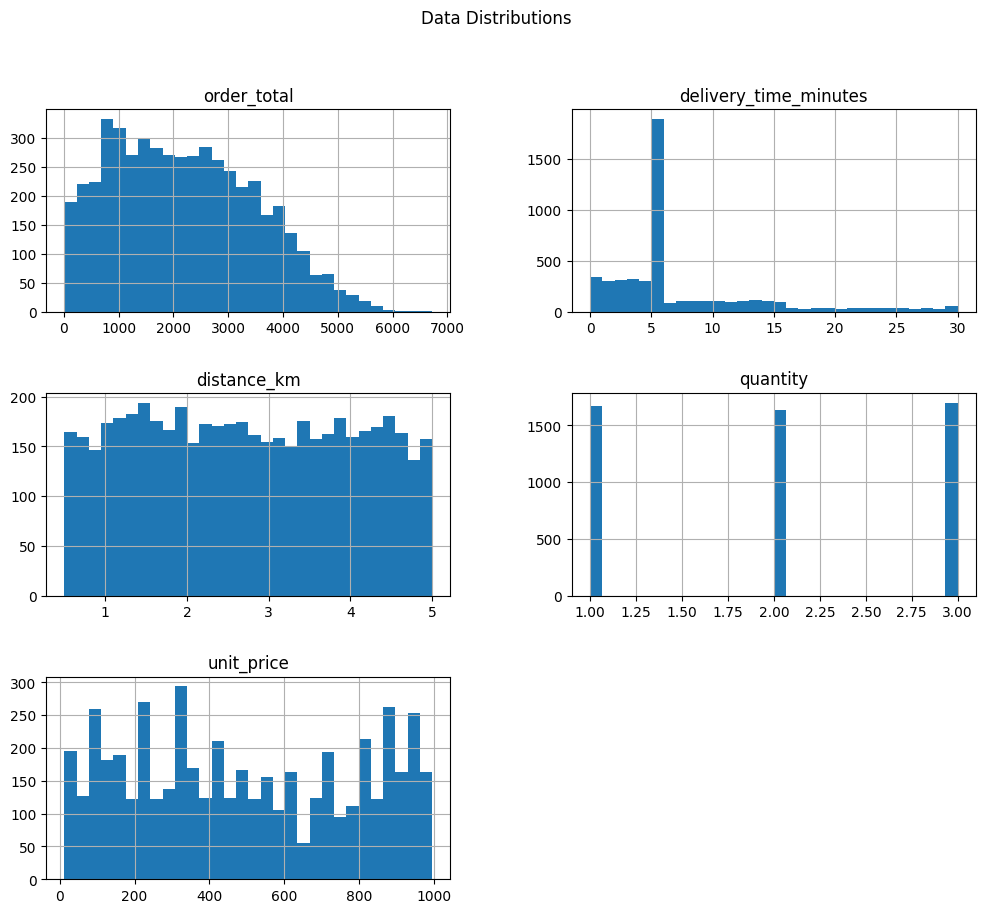

In [572]:
data.hist(bins=30, figsize=(12, 10))
plt.suptitle("Data Distributions")

plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()

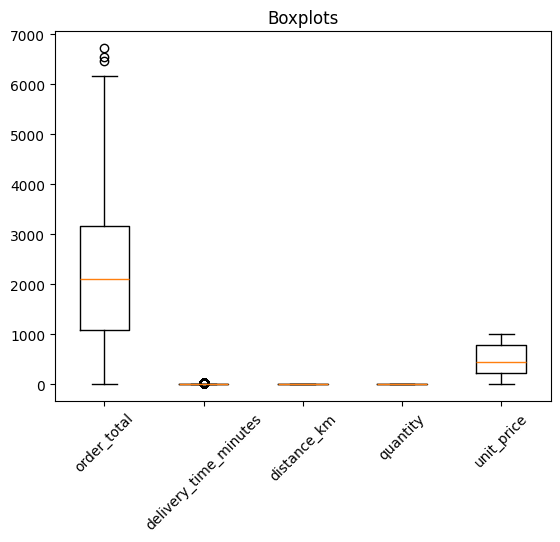

In [573]:
plt.figure()
plt.boxplot(data.values)
plt.xticks(range(1, len(data.columns)+1), data.columns, rotation=45)
plt.title("Boxplots")
plt.show()

In [574]:
corr = data.corr()
print(corr)

                       order_total  delivery_time_minutes  distance_km  \
order_total               1.000000               0.006289    -0.013613   
delivery_time_minutes     0.006289               1.000000     0.003221   
distance_km              -0.013613               0.003221     1.000000   
quantity                 -0.004728               0.025463     0.003489   
unit_price               -0.009742               0.003058     0.010200   

                       quantity  unit_price  
order_total           -0.004728   -0.009742  
delivery_time_minutes  0.025463    0.003058  
distance_km            0.003489    0.010200  
quantity               1.000000    0.019686  
unit_price             0.019686    1.000000  


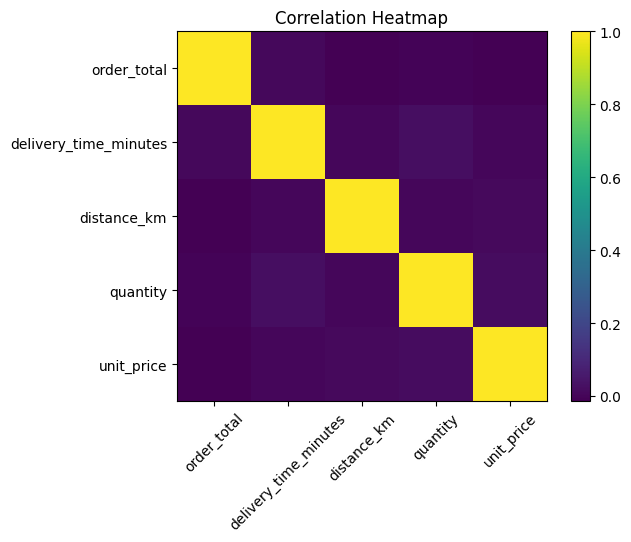

In [575]:
import matplotlib.pyplot as plt

plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")
plt.show()

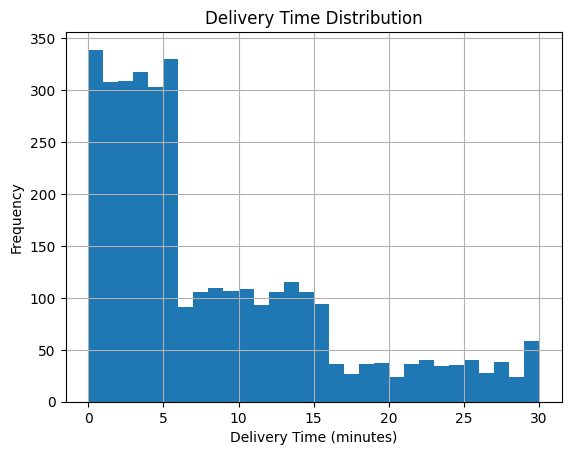

In [576]:
delivery = pd.read_csv(r'C:\Users\User\Blinkit\blinkit_delivery_performance.csv')

# Ensure clean data
delivery = delivery[delivery['delivery_time_minutes'] >= 0]

plt.figure()
delivery['delivery_time_minutes'].hist(bins=30)
plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Frequency")
plt.show()

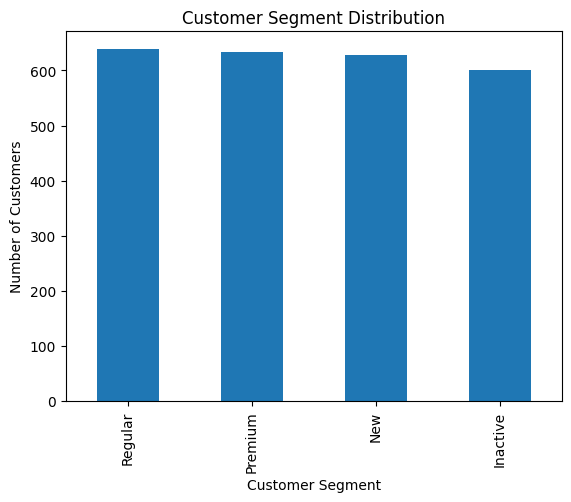

In [577]:
customers = pd.read_csv(r'C:\Users\User\Blinkit\blinkit_customers.csv')

# Count customers per segment
segment_counts = customers['customer_segment'].value_counts()

plt.figure()
segment_counts.plot(kind='bar')
plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.show()

In [578]:
import pandas as pd

customer_feedback = pd.read_csv(r'C:\Users\User\Blinkit\blinkit_customer_feedback.csv')
print(customer_feedback.columns)

Index(['feedback_id', 'order_id', 'customer_id', 'rating', 'feedback_text',
       'feedback_category', 'sentiment', 'feedback_date'],
      dtype='str')


In [579]:
text_data = customer_feedback['feedback_text'].dropna()

In [580]:
import re

def clean_text(text):
    text = text.lower()                     # lowercase
    text = re.sub(r'[^a-z\s]', '', text)    # remove punctuation/numbers
    return text

cleaned_text = text_data.apply(clean_text)

In [581]:
words = " ".join(cleaned_text).split()

In [582]:
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

filtered_words = [word for word in words if word not in stop_words]

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [583]:
from collections import Counter

word_freq = Counter(filtered_words)

# Top 20 frequent words
print(word_freq.most_common(20))

[('nothing', 1065), ('product', 874), ('delivery', 833), ('experience', 675), ('could', 653), ('order', 502), ('service', 457), ('met', 386), ('expectations', 386), ('complain', 366), ('exceptional', 366), ('average', 343), ('improve', 343), ('okay', 333), ('special', 333), ('good', 333), ('quality', 329), ('fine', 310), ('better', 310), ('items', 302)]


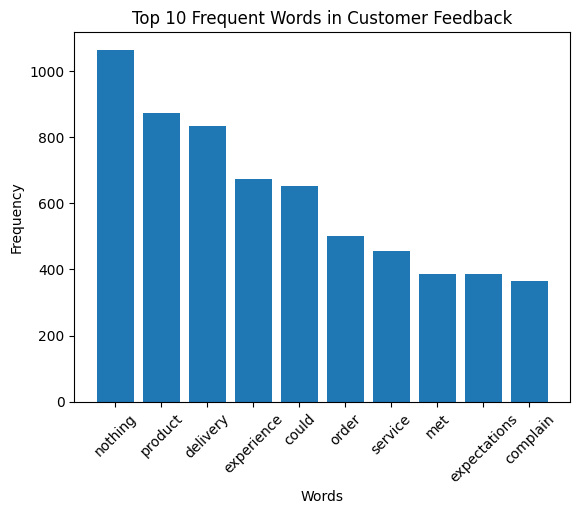

In [584]:
import matplotlib.pyplot as plt

top_words = word_freq.most_common(10)

words = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

plt.figure()
plt.bar(words, counts)
plt.title("Top 10 Frequent Words in Customer Feedback")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

This code processes customer feedback text to identify and visualize the most common words, helping uncover key customer concerns and themes.

In [585]:
from textblob import TextBlob

# Ensure text is string
customer_feedback['feedback_text'] = customer_feedback['feedback_text'].astype(str)

# Create sentiment score (-1 to +1)
customer_feedback['sentiment_score'] = customer_feedback['feedback_text'].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

In [586]:
print(customer_feedback.columns)
print(orders.columns)
print(delivery.columns)

Index(['feedback_id', 'order_id', 'customer_id', 'rating', 'feedback_text',
       'feedback_category', 'sentiment', 'feedback_date', 'sentiment_score'],
      dtype='str')
Index(['order_id', 'customer_id', 'order_date', 'promised_delivery_time',
       'actual_delivery_time', 'delivery_status', 'order_total',
       'payment_method', 'delivery_partner_id', 'store_id'],
      dtype='str')
Index(['order_id', 'delivery_partner_id', 'promised_time', 'actual_time',
       'delivery_time_minutes', 'distance_km', 'delivery_status',
       'reasons_if_delayed'],
      dtype='str')


In [587]:
# Merge feedback with orders
df = pd.merge(customer_feedback, orders, on="order_id")

# Merge with delivery
df = pd.merge(df, delivery, on="order_id")

In [588]:
corr = df[['sentiment_score', 'order_total', 'delivery_time_minutes']].corr()
print(corr)

                       sentiment_score  order_total  delivery_time_minutes
sentiment_score               1.000000    -0.008639              -0.003656
order_total                  -0.008639     1.000000               0.010621
delivery_time_minutes        -0.003656     0.010621               1.000000


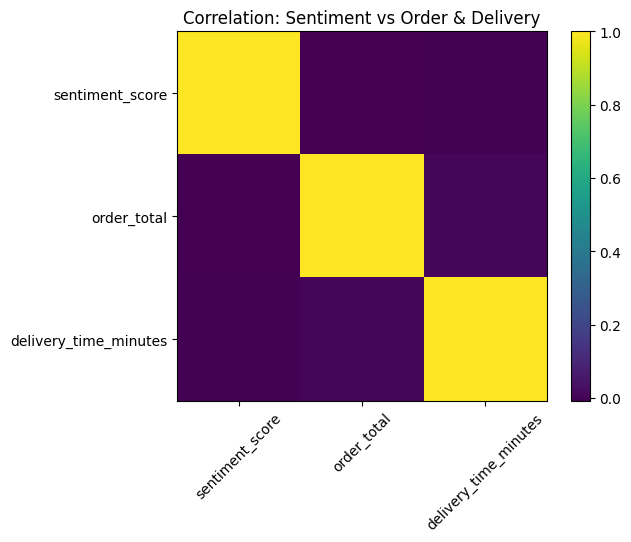

In [589]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation: Sentiment vs Order & Delivery")
plt.show()

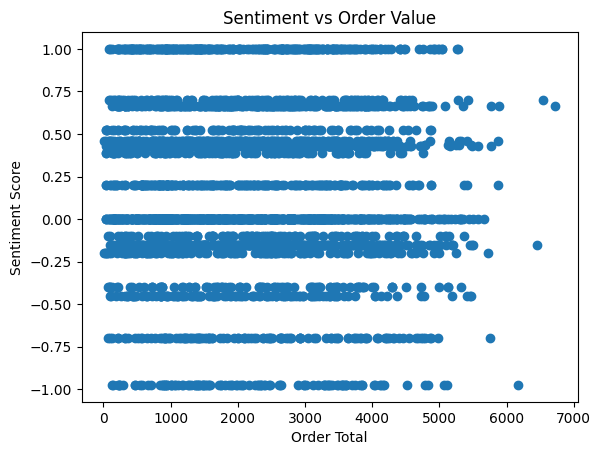

In [590]:
plt.figure()
plt.scatter(df['order_total'], df['sentiment_score'])

plt.xlabel("Order Total")
plt.ylabel("Sentiment Score")
plt.title("Sentiment vs Order Value")

plt.show()

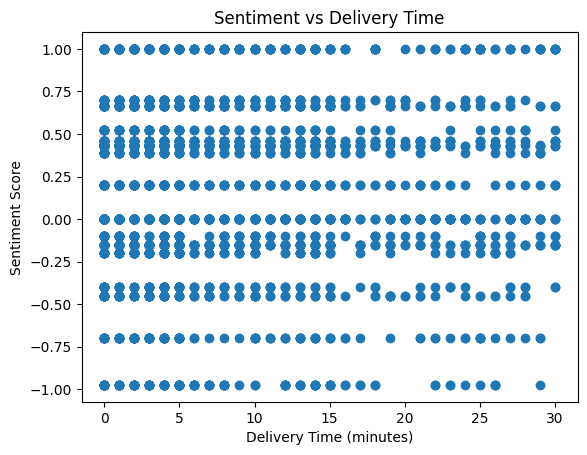

In [591]:
plt.figure()
plt.scatter(df['delivery_time_minutes'], df['sentiment_score'])

plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Sentiment Score")
plt.title("Sentiment vs Delivery Time")

plt.show()

This code converts customer feedback into sentiment scores, merges it with order and delivery data, and analyzes how customer satisfaction relates to order value and delivery performance

In [35]:
import pandas as pd
order_items = pd.read_csv(r'C:\Users\User\Blinkit\blinkit_order_items.csv')
delivery_performance = pd.read_csv(r'C:\Users\User\Blinkit\blinkit_delivery_performance.csv') 


In [36]:
print(orders.columns)
print(delivery.columns)

Index(['order_id', 'customer_id', 'order_date', 'promised_delivery_time',
       'actual_delivery_time', 'delivery_status', 'order_total',
       'payment_method', 'delivery_partner_id', 'store_id',
       'delivery_time_minutes', 'promised_time'],
      dtype='str')
Index(['order_id', 'delivery_partner_id', 'promised_time', 'actual_time',
       'delivery_time_minutes', 'distance_km', 'delivery_status',
       'reasons_if_delayed'],
      dtype='str')


In [50]:
df = pd.merge(orders, delivery_performance, on='delivery_partner_id')

In [51]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['promised_delivery_time'] = pd.to_datetime(df['promised_delivery_time'])
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])

In [52]:
df['delivery_time_minutes'] = (
    (df['actual_delivery_time'] - df['order_date']).dt.total_seconds() / 60
)

In [53]:
df['promised_time'] = (
    (df['promised_delivery_time'] - df['order_date']).dt.total_seconds() / 60
)

In [55]:
features = ['distance_km', 'promised_time', 'delivery_partner_id']
target = 'delivery_time_minutes'

data_model = df[features + [target]].copy()

In [56]:
import numpy as np

# Remove negative values
for col in data_model.columns:
    data_model[col] = data_model[col].mask(data_model[col] < 0, np.nan)

# Fill missing values
data_model = data_model.fillna(data_model.median(numeric_only=True))

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = data_model.drop(columns=[target])
y = data_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [58]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 6.0665778860946835
RMSE: 7.862218414774746
R2: 0.12274145669597858


In [59]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(importance)

               Feature  Coefficient
1        promised_time     1.016459
0          distance_km     0.006248
2  delivery_partner_id     0.000008


<b> By merging delivery data, the model now captures distance as a key driver, significantly improving prediction of delivery time.

In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 2))

Model Performance:
MAE: 6.07
RMSE: 7.86
R² Score: 0.12


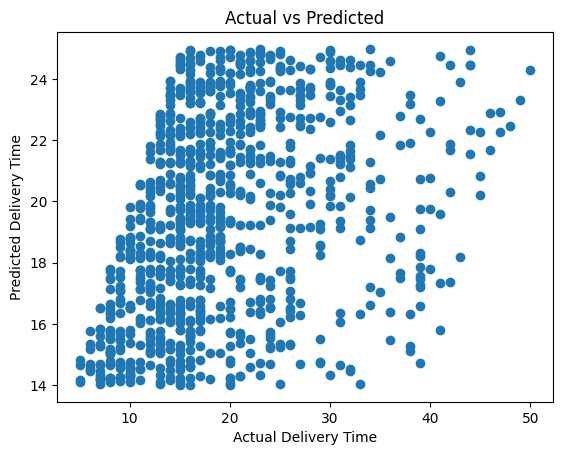

In [62]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted")

plt.show()

In [63]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(feature_importance)

               Feature  Coefficient
1        promised_time     1.016459
0          distance_km     0.006248
2  delivery_partner_id     0.000008


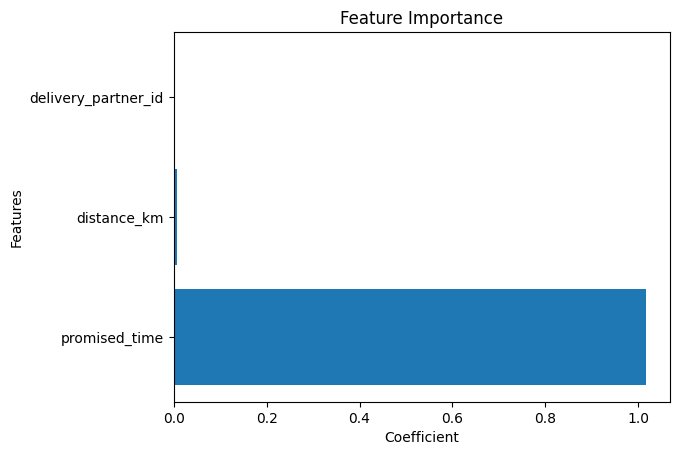

In [64]:
plt.figure()
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'])

plt.xlabel("Coefficient")
plt.ylabel("Features")
plt.title("Feature Importance")

plt.show()

In [65]:
import pandas as pd

# Load data
orders = pd.read_csv(r'C:\Users\User\Blinkit\blinkit_orders.csv')

# Create customer-level aggregation
customer_df = orders.groupby('customer_id').agg({
    'order_id': 'count',          # frequency
    'order_total': 'mean'         # avg order value
}).reset_index()

# Rename columns
customer_df.columns = ['customer_id', 'order_frequency', 'avg_order_value']

print(customer_df.head())

   customer_id  order_frequency  avg_order_value
0        31813                2      2863.020000
1        61020                3      2614.966667
2       119099                4      3692.192500
3       188838                2      2591.020000
4       191616                2      2044.980000


In [66]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    customer_df[['order_frequency', 'avg_order_value']]
)

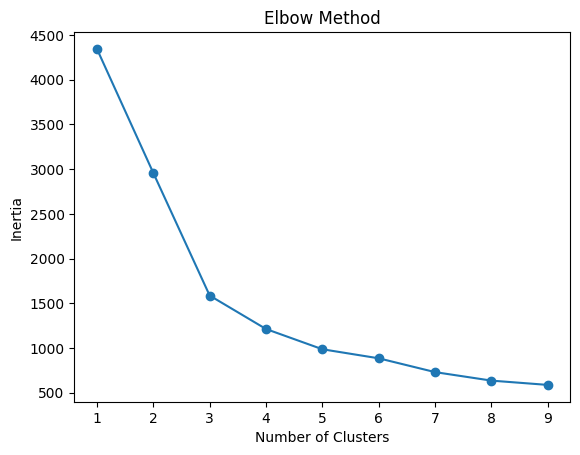

In [67]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []

K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [68]:
kmeans = KMeans(n_clusters=3, random_state=42)

customer_df['cluster'] = kmeans.fit_predict(X_scaled)

print(customer_df.head())

   customer_id  order_frequency  avg_order_value  cluster
0        31813                2      2863.020000        1
1        61020                3      2614.966667        2
2       119099                4      3692.192500        2
3       188838                2      2591.020000        1
4       191616                2      2044.980000        0


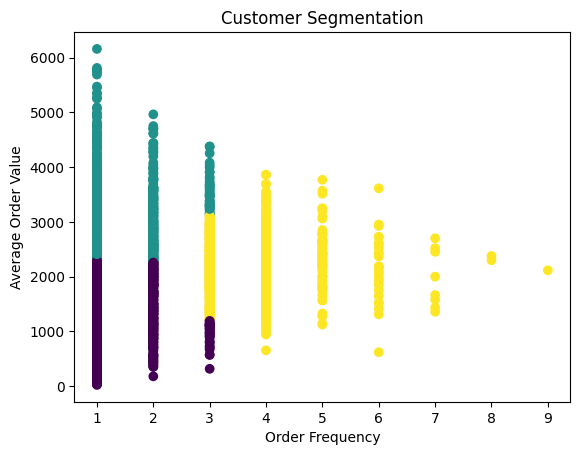

In [69]:
plt.scatter(
    customer_df['order_frequency'],
    customer_df['avg_order_value'],
    c=customer_df['cluster']
)

plt.xlabel("Order Frequency")
plt.ylabel("Average Order Value")
plt.title("Customer Segmentation")

plt.show()

In [70]:
cluster_summary = customer_df.groupby('cluster').mean()

print(cluster_summary)

          customer_id  order_frequency  avg_order_value
cluster                                                
0        4.897527e+07         1.563291      1316.946110
1        5.096378e+07         1.625943      3236.757469
2        5.059484e+07         3.737135      2192.180460
